In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

summary_df = pd.read_csv('../data/vessel_summary.csv')
cmp_df = pd.read_csv('../data/flag_change_intervals.csv')
identities_df = pd.read_csv('../data/identities.csv')
flags_df = pd.read_csv('../data/flag_df.csv')
shadow_FV = pd.read_csv('../data/shadow_FV.csv')

url = ('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/'
       'master/geojson/ne_110m_admin_0_countries.geojson')
from pathlib import Path
Path('../reports').mkdir(exist_ok=True)

plt.savefig('../reports/ism_map.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

#### Visualization of the frequency of flag changes up to 2023 and thereafter

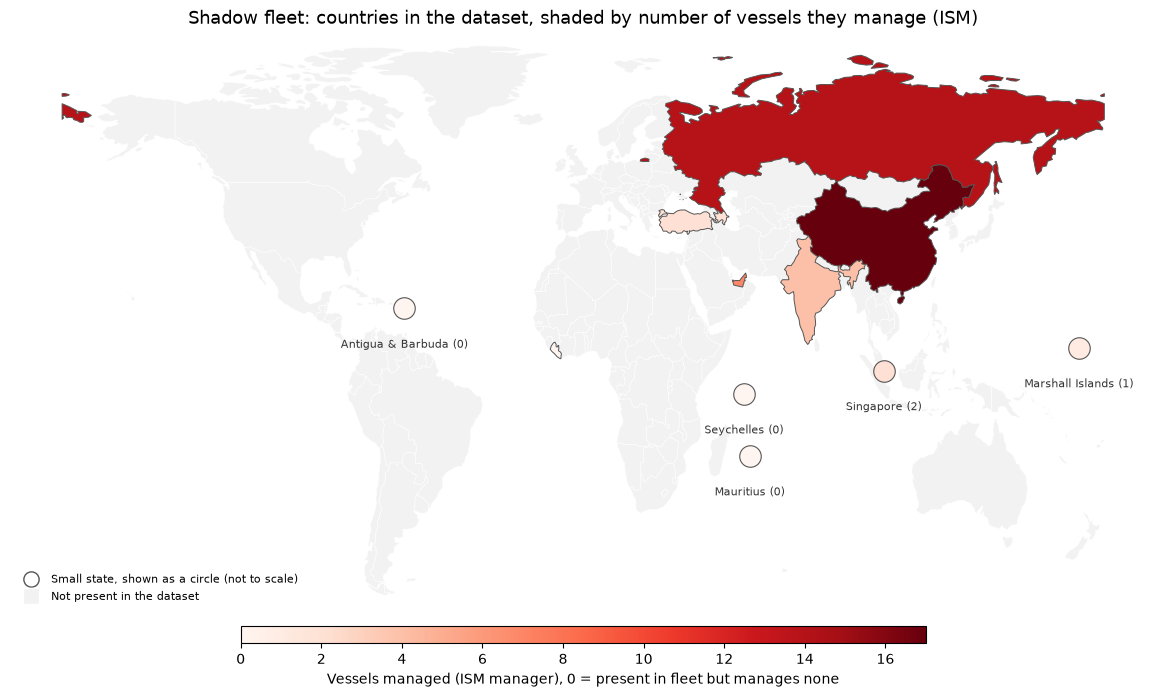

In [15]:
from shapely.geometry import Polygon

all_countries = set(shadow_FV['reg_country']) | set(shadow_FV['ism_country']) | set(shadow_FV['manager_country'])
all_countries = sorted(c for c in all_countries if c != 'Unknown')
ism_counts = shadow_FV['ism_country'].value_counts()

NE_NAME = {'UAE': 'United Arab Emirates'}          # our name -> map name
SMALL_STATES = {                                   # too small to see at this resolution
    'Singapore': (103.8, 1.3), 'Marshall Islands': (171.2, 7.1),
    'Seychelles': (55.5, -4.6), 'Mauritius': (57.5, -20.3),
    'Antigua & Barbuda': (-61.8, 17.1),
}

data = pd.DataFrame({'country': all_countries})
data['ism'] = data['country'].map(ism_counts).fillna(0).astype(int)
data['ne_name'] = data['country'].map(NE_NAME).fillna(data['country'])

# ---------- 2. base map ----------
world = gpd.read_file(url)

# Natural Earth draws Crimea inside Russia - move it to Ukraine
CRIMEA = Polygon([
    (34.73, 45.97), (35.48, 45.30), (35.79, 45.43), (36.60, 45.50), (36.45, 45.00),
    (35.81, 45.03), (35.51, 45.11), (35.36, 44.96), (34.47, 44.73), (33.93, 44.30),
    (33.30, 44.55), (33.50, 44.62), (33.45, 45.12), (32.40, 45.30), (32.55, 45.55),
    (33.69, 45.86), (33.78, 45.93), (33.62, 45.95), (33.70, 46.25),
]).buffer(0.1)

ru = world.index[world['ADMIN'] == 'Russia'][0]
ua = world.index[world['ADMIN'] == 'Ukraine'][0]
rus = world.at[ru, 'geometry']
world.at[ua, 'geometry'] = world.at[ua, 'geometry'].union(rus.intersection(CRIMEA))
world.at[ru, 'geometry'] = rus.difference(CRIMEA)

world = world.merge(data[['ne_name', 'ism']], left_on='ADMIN', right_on='ne_name', how='left')

# ---------- 3. plot ----------
cmap, norm = plt.get_cmap('Reds'), Normalize(vmin=0, vmax=ism_counts.max())

fig, ax = plt.subplots(figsize=(14, 7.5))
world.plot(ax=ax, color='#F2F2F2', edgecolor='white', linewidth=0.4)                 # rest of the world
world.dropna(subset=['ism']).plot(column='ism', cmap=cmap, norm=norm, ax=ax,
                                  edgecolor='#555555', linewidth=0.7)                # our countries

drawn = set(world.loc[world['ism'].notna(), 'ADMIN'])
for name, (lon, lat) in SMALL_STATES.items():
    if name not in all_countries or NE_NAME.get(name, name) in drawn:
        continue
    n = int(data.loc[data['country'] == name, 'ism'].iloc[0])
    ax.scatter(lon, lat, s=240, color=cmap(norm(n)), edgecolor='#555555', linewidth=0.8, zorder=5)
    ax.annotate(f'{name} ({n})', xy=(lon, lat), xytext=(lon, lat - 10),
                ha='center', fontsize=8, color='#333333', zorder=6)

cbar = fig.colorbar(ScalarMappable(cmap=cmap, norm=norm), ax=ax,
                    orientation='horizontal', shrink=0.5, pad=0.02, aspect=40)
cbar.set_label('Vessels managed (ISM manager), 0 = present in fleet but manages none')

ax.legend(handles=[
    Line2D([], [], marker='o', linestyle='none', markersize=11, markerfacecolor='none',
           markeredgecolor='#555555', label='Small state, shown as a circle (not to scale)'),
    Line2D([], [], marker='s', linestyle='none', markersize=11, markerfacecolor='#F2F2F2',
           markeredgecolor='white', label='Not present in the dataset')],
    loc='lower left', frameon=False, fontsize=8)

ax.set_title('Shadow fleet: countries in the dataset, shaded by number of vessels they manage (ISM)',
             fontsize=13, pad=12)
ax.set_axis_off()
ax.set_ylim(-60, 85)
plt.tight_layout()

Path('../reports').mkdir(exist_ok=True)
plt.savefig('../reports/ism_map.png', dpi=150, bbox_inches='tight')
plt.show()

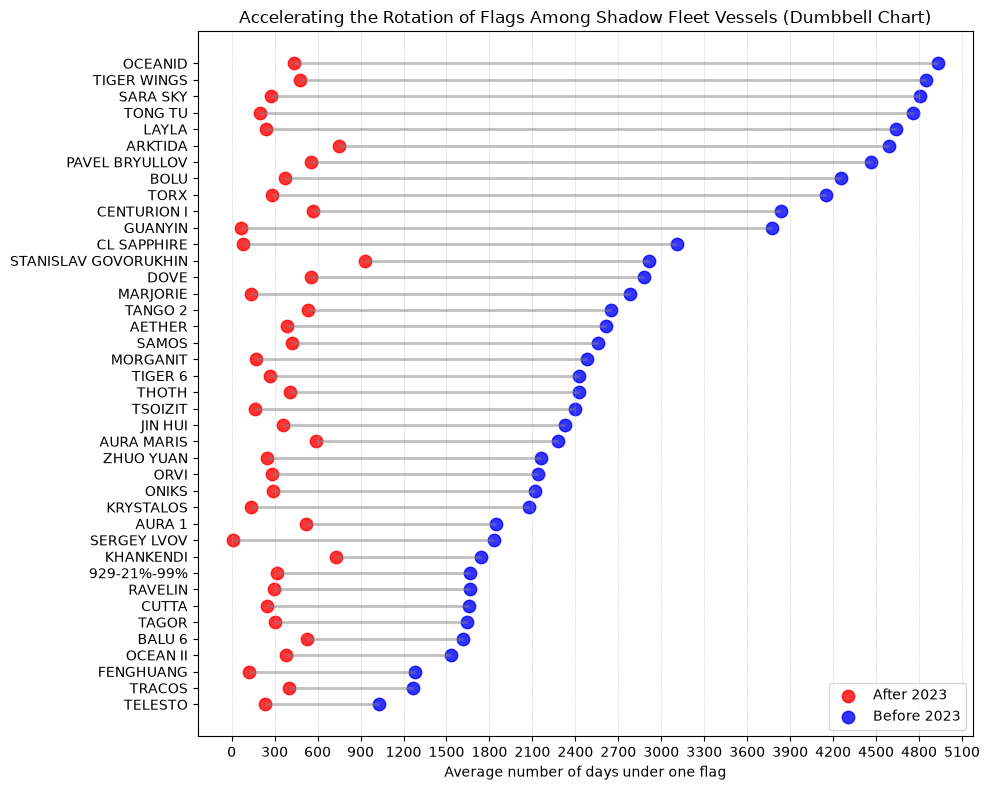

In [16]:

df = identities_df.copy()
df['transmission_from'] = pd.to_datetime(
    df['transmission_from'], format='mixed', utc=True
)
df['transmission_to'] = pd.to_datetime(
    df['transmission_to'], format='mixed', utc=True
)
# If transmission_to is null, use the current date (or data export date)
df['transmission_to'] = df['transmission_to'].fillna(pd.Timestamp.now(tz='UTC'))
df['duration_days'] = (df['transmission_to'] - df['transmission_from']).dt.days

# 2. Split into periods (before 2023 and after)
df['period'] = df['transmission_from'].apply(
    lambda x: 'before_2023' if x.year < 2023 else 'after_2023'
)

# 3. Calculate average flag ownership duration per IMO for each period
grouped = df.groupby(['imo', 'period'])['duration_days'].mean().unstack()

# Keep only vessels with data for both periods and reset index to keep IMO as a column
plot_data = grouped.dropna().reset_index()

plot_data = plot_data.merge(summary_df[['imo', 'current_name']], on='imo')

plt.figure(figsize=(10, 8))
# Sort by "before_2023" duration for visual clarity
plot_data = plot_data.sort_values('before_2023')

plt.hlines(
    y=plot_data['current_name'],
    xmin=plot_data['after_2023'],
    xmax=plot_data['before_2023'],
    color='grey',
    alpha=0.5,
    linewidth=2,
)

# Draw points
plt.scatter(
    plot_data['after_2023'],
    plot_data['current_name'],
    color='red',
    alpha=0.8,
    label='After 2023',
    s=80,
)
plt.scatter(
    plot_data['before_2023'],
    plot_data['current_name'],
    color='blue',
    alpha=0.8,
    label='Before 2023',
    s=80,
)
plt.xticks(np.arange(0, plot_data['before_2023'].max() + 300, 300))
plt.legend()
plt.xlabel('Average number of days under one flag')
plt.title(
    'Accelerating the Rotation of Flags Among Shadow Fleet Vessels (Dumbbell Chart)'
)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

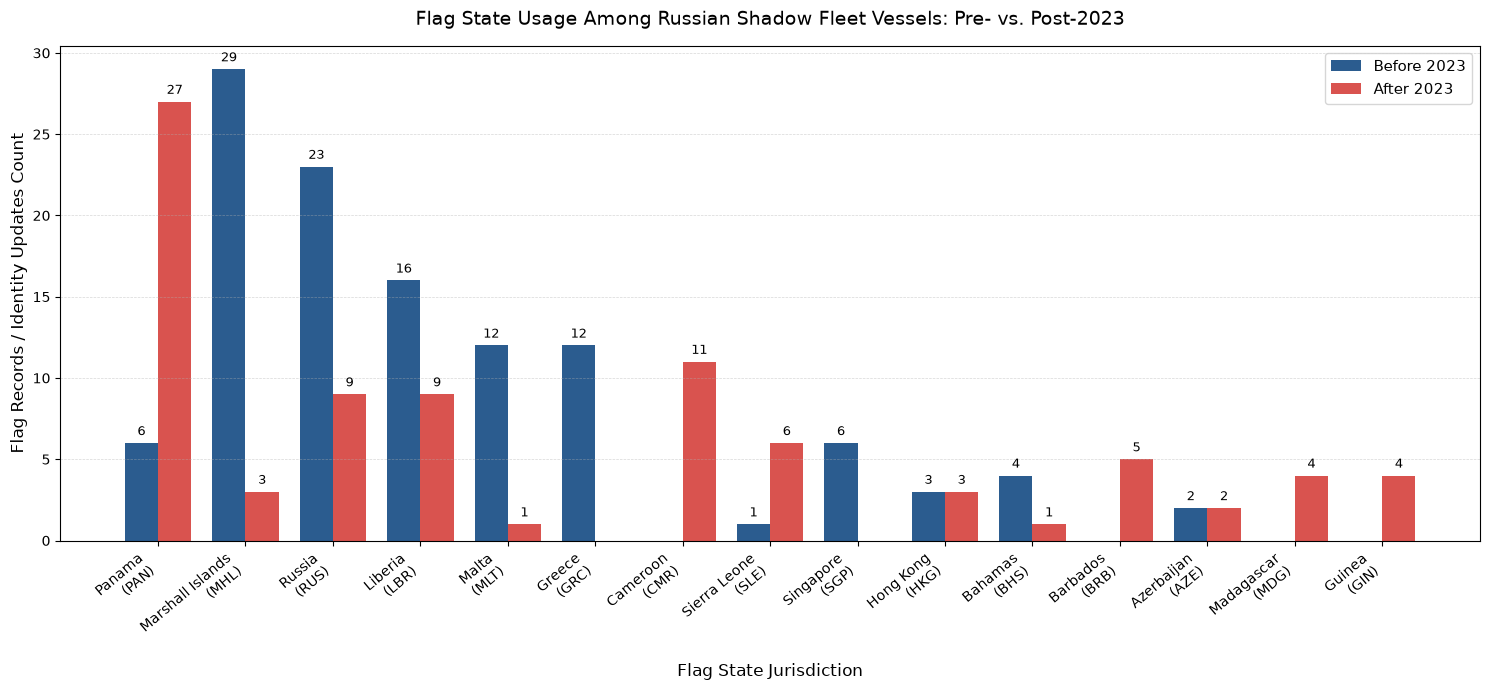

In [17]:
# Parse datetime and filter out records with missing flags
identities_df['transmission_from'] = pd.to_datetime(
    identities_df['transmission_from'], format='mixed', utc=True
)
df_flags = identities_df.dropna(subset=['flag']).copy()

df_flags['period'] = df_flags['transmission_from'].apply(
    lambda x: 'Before 2023' if x.year < 2023 else 'After 2023'
)

flag_counts = df_flags.groupby(['flag', 'period']).size().unstack(fill_value=0)
flag_counts['total'] = flag_counts['Before 2023'] + flag_counts['After 2023']


top_flags = flag_counts.sort_values(by='total', ascending=False).head(15)


iso_to_country = {
    'PAN': 'Panama',
    'MHL': 'Marshall Islands',
    'RUS': 'Russia',
    'LBR': 'Liberia',
    'CMR': 'Cameroon',
    'MLT': 'Malta',
    'SLE': 'Sierra Leone',
    'BRB': 'Barbados',
    'GRC': 'Greece',
    'MDG': 'Madagascar',
    'HKG': 'Hong Kong',
    'SGP': 'Singapore',
    'PLW': 'Palau',
    'BHS': 'Bahamas',
    'GIN': 'Guinea',
    'COM': 'Comoros',
    'NIC': 'Nicaragua',
    'CHN': 'China',
    'AZE': 'Azerbaijan',
    'DEU': 'Germany',
    'TUR': 'Turkey',
    'GNQ': 'Equatorial Guinea',
    'COK': 'Cook Islands',
    'SYR': 'Syria',
    'ITA': 'Italy',
    'SAU': 'Saudi Arabia',
    'BES': 'Caribbean Netherlands',
    'ATG': 'Antigua and Barbuda',
    'CYP': 'Cyprus',
    'CYM': 'Cayman Islands',
    'FRA': 'France',
    'ESP': 'Spain',
    'DNK': 'Denmark',
    'KWT': 'Kuwait',
    'IMN': 'Isle of Man',
    'VUT': 'Vanuatu',
    'SMR': 'San Marino',
    'MOZ': 'Mozambique',
    'CAN': 'Canada',
}

top_flags['label'] = top_flags.index.map(
    lambda x: f'{iso_to_country.get(x, x)}\n({x})'
)


plt.figure(figsize=(15, 7))
x = np.arange(len(top_flags))
width = 0.38

bars_before = plt.bar(
    x - width / 2,
    top_flags['Before 2023'],
    width,
    label='Before 2023',
    color='#2b5c8f',
)
bars_after = plt.bar(
    x + width / 2,
    top_flags['After 2023'],
    width,
    label='After 2023',
    color='#d9534f',
)

plt.xlabel('Flag State Jurisdiction', fontsize=12, labelpad=10)
plt.ylabel('Flag Records / Identity Updates Count', fontsize=12)
plt.title(
    'Flag State Usage Among Russian Shadow Fleet Vessels: Pre- vs. Post-2023',
    fontsize=14,
    pad=15,
)
plt.xticks(x, top_flags['label'], rotation=40, ha='right', fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add numerical value annotations above bars
for bar in bars_before:
  h = bar.get_height()
  if h > 0:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        int(h),
        ha='center',
        va='bottom',
        fontsize=9,
    )

for bar in bars_after:
  h = bar.get_height()
  if h > 0:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        int(h),
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()